In [1]:
import scipy.io.wavfile as wf
from scipy import signal
import numpy as np

In [2]:
sample_rate , data = wf.read("task5_1.wav")

if len(data.shape) == 2:
    data = data.mean(axis=1)

print(len(data.shape))

1


In [3]:
#low pass filter
cutoff_freq = 1000
low_order = 4

low_b, low_a = signal.butter(low_order, cutoff_freq, btype="low", fs = sample_rate)
low_pass_audio = signal.filtfilt(low_b,low_a,data)

In [4]:
#notch filter
notch_freq = 60
notch_Q = 30

notch_b, notch_a = signal.iirnotch(notch_freq, notch_Q, fs=sample_rate)

final_audio = signal.filtfilt(notch_b, notch_a, low_pass_audio)

In [5]:
final_audio = np.int16(final_audio / np.max(np.abs(final_audio)) * 32767)

wf.write('filtered_output.wav', sample_rate, final_audio)

ok it didn't work it just made it "Quiter"? i will try to see the graph

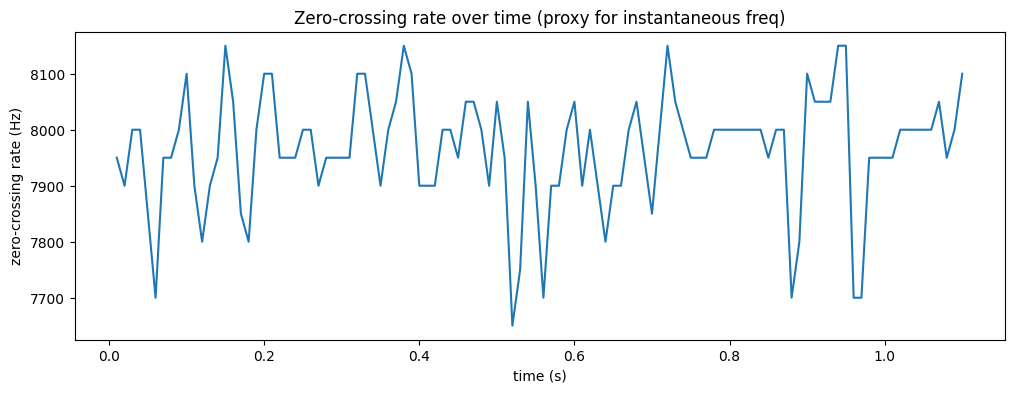

In [6]:
import matplotlib.pyplot as plt

data = data.astype(float)         

win = int(0.020 * sample_rate)               
hop = int(0.010 * sample_rate)              

times, zcr = [], []
for s in range(0, len(data) - win, hop):
    fr = data[s:s + win]
    n_cross = np.sum(fr[:-1] * fr[1:] < 0)   
    zcr.append(n_cross * sample_rate / win)           
    times.append((s + win / 2) / sample_rate)  

plt.figure(figsize=(12, 4))
plt.plot(times, zcr)
plt.title("Zero-crossing rate over time (proxy for instantaneous freq)")
plt.xlabel("time (s)")
plt.ylabel("zero-crossing rate (Hz)")
plt.show()

okay after some research i decided on a Multi-pass spectral spike suppression and Bandpass filtering

In [12]:
import scipy.io.wavfile as wf
import numpy as np
from scipy.signal import medfilt, butter, filtfilt

sr, data = wf.read("task5_1.wav")
data = data.astype(float)
data = data - data.mean()

def suppress_tonal_spikes(x, sr, threshold, neighbor_width, floor_kernel=101):
    N = len(x)
    X = np.fft.rfft(x)
    mag = np.abs(X)
    floor = medfilt(mag, kernel_size=floor_kernel)
    ratio = mag / (floor + 1e-9)
    
    spike_bins = np.where(ratio > threshold)[0]
    
    mask = np.zeros(len(mag), dtype=bool)
    for b in spike_bins:
        lo = max(0, b - neighbor_width)
        hi = min(len(mag), b + neighbor_width + 1)
        mask[lo:hi] = True
    
    X_clean = X.copy()
    idx = np.arange(len(mag))
    good = ~mask
    interp_mag = np.interp(idx, idx[good], mag[good])
    X_clean[mask] = interp_mag[mask] * np.exp(1j * np.angle(X[mask]))
    
    return np.fft.irfft(X_clean, n=N), mask.sum()

cleaned = data.copy()
for thresh in [3.0 ,2.5, 2.0, 1.5,]:
    cleaned, n_suppressed = suppress_tonal_spikes(cleaned, sr, threshold=thresh, neighbor_width=10)

b, a = butter(6, [250, 3500], btype='band', fs=sr)
cleaned_band = filtfilt(b, a, cleaned)

norm = cleaned_band / (np.max(np.abs(cleaned_band)) + 1e-9)
audio = np.int16(norm * 32767 * 0.95)
wf.write("spectral_denoise_bandpassed.wav", sr, audio)

i can make it out. the word is ```"Translate"```